## Problem 1: Proving Eulers Formula

In [66]:
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp

sp.init_printing()
theta = sp.symbols('theta', real=True)

lhs_euler = sp.exp(sp.I * theta)
rhs_euler = sp.cos(theta) + sp.I * sp.sin(theta)



In [67]:
order = 12
lhs_series = sp.series(lhs_euler, theta, 0, order).removeO()
rhs_series = sp.series(rhs_euler, theta, 0, order).removeO()


In [68]:
sp.Eq(sp.expand(lhs_series), sp.expand(rhs_series))


## Problem 2: Numerical Example of SVD Pseudo-inverse

In [60]:
A = np.array([[1.0, 1.0, 1.0]])
b = np.array([10.0])

x_pinv = np.linalg.pinv(A) @ b

In [61]:
print(f"pseudoinverse solution: x⁺ = {x_pinv}")
print(f"||x⁺||² = {np.linalg.norm(x_pinv)**2:.4f}")

pseudoinverse solution: x⁺ = [3.33333333 3.33333333 3.33333333]
||x⁺||² = 33.3333


In [50]:
alternatives = [
    ([10, 0, 0], "All in x₁"),
    ([0, 10, 0], "All in x₂"),
    ([5, 5, 0], "Split x₁, x₂"),
    ([4, 3, 3], "Unequal split"),
    ([10/3, 10/3, 10/3], "Equal split (x⁺)"),
]

print(f"\n{'Solution':<25} {'||x||²':<12} {'Note'}")
for sol, desc in alternatives:
    x = np.array(sol)
    print(f"{str(sol):<25} {np.linalg.norm(x)**2:<12.4f} {desc}")


Solution                  ||x||²       Note
[10, 0, 0]                100.0000     All in x₁
[0, 10, 0]                100.0000     All in x₂
[5, 5, 0]                 50.0000      Split x₁, x₂
[4, 3, 3]                 34.0000      Unequal split
[3.3333333333333335, 3.3333333333333335, 3.3333333333333335] 33.3333      Equal split (x⁺)


We can see that the pseudo-inverse, equal split, is the closest option to $||x||^2$

## Overdetermined systen

In [52]:
A = np.array([[1], [1], [1]])
b = np.array([1, 2, 6])
x_pinv = np.linalg.pinv(A) @ b
r_opt = A @ x_pinv - b

In [53]:
print(f"x⁺ = {x_pinv[0]:.4f}, r⁺ = {r_opt}, ||r⁺||² = {np.linalg.norm(r_opt)**2:.4f}")

for delta in [0.5, 1.0, 2.0]:
    v = np.array([delta])
    r_pert = r_opt + (A @ v).flatten()
    
    actual_res_sq = np.linalg.norm(r_pert)**2
    predicted_res_sq = np.linalg.norm(r_opt)**2 + np.linalg.norm(A @ v)**2
    
    print(f"δ={delta}: ||r⁺+Av||² = {actual_res_sq:.4f}, "
          f"||r⁺||² + ||Av||² = {predicted_res_sq:.4f}, "
          f"match: {np.isclose(actual_res_sq, predicted_res_sq)}")


x⁺ = 3.0000, r⁺ = [ 2.  1. -3.], ||r⁺||² = 14.0000
δ=0.5: ||r⁺+Av||² = 14.7500, ||r⁺||² + ||Av||² = 14.7500, match: True
δ=1.0: ||r⁺+Av||² = 17.0000, ||r⁺||² + ||Av||² = 17.0000, match: True
δ=2.0: ||r⁺+Av||² = 26.0000, ||r⁺||² + ||Av||² = 26.0000, match: True


We could also try this for a rank deficient system, which would have characteristics of both of the above system types, since it should be able to get the minimum norm in closest fit, and for minimum residual

In [62]:
A = np.array([
    [1, 1],
    [1, 1],
    [2, 2]
])
b = np.array([3, 3.1, 6])

U, S, Vt = np.linalg.svd(A, full_matrices=True)
x_pinv = np.linalg.pinv(A) @ b
sum_val = x_pinv[0] + x_pinv[1]
for t in [0, 1, 1.5, sum_val/2, 2, 3]:
    x_test = np.array([t, sum_val - t])
    res = np.linalg.norm(A @ x_test - b)**2
    norm_sq = np.linalg.norm(x_test)**2
    print(f"{t:<10.4f} {str(x_test):<25} {norm_sq:<15.6f} {res:.6f}{marker}")

0.0000     [0.         3.01666667]   9.100278        0.008333
1.0000     [1.         2.01666667]   5.066944        0.008333
1.5000     [1.5        1.51666667]   4.550278        0.008333
1.5083     [1.50833333 1.50833333]   4.550139        0.008333
2.0000     [2.         1.01666667]   5.033611        0.008333
3.0000     [3.         0.01666667]   9.000278        0.008333


We see the minimum norm occuring at 1.5

## Problem 3: Proof of SVD Pseudoinverse minimum norm and maximum norm

### Undetermined problem
In an underdetermined problem, there is an infinite number of possible solutions for a given vector x. They are going to form the hyperplane relative to the origin, but will never intersect it. So what we need to be able to find the "closest" point on that line to the origin. 

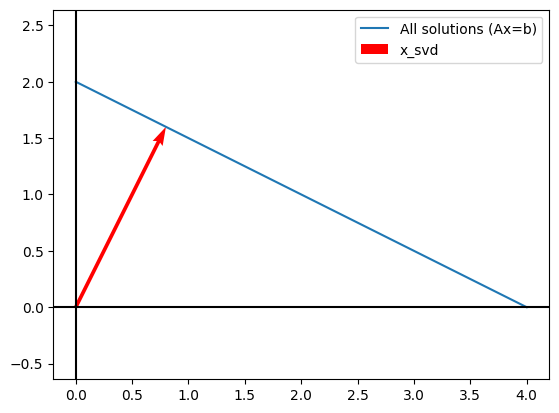

In [41]:
import matplotlib.pyplot as plt
import numpy as np

A = np.array([[1, 2]])
b = np.array([4])
x_svd = np.linalg.pinv(A) @ b
x_vals = np.linspace(0, 4, 100)
y_vals = (4 - x_vals) / 2

plt.plot(x_vals, y_vals, label='All solutions (Ax=b)')
plt.quiver(0, 0, x_svd[0], x_svd[1], angles='xy', scale_units='xy', scale=1, color='r', label='x_svd')
plt.axis('equal')
plt.axhline(0, color='black')
plt.axvline(0, color='black')
plt.legend()
plt.show()


The common notation we will use is: 

$Ax = v$ where $A$ is an $mxn$ matrix, $v$ and $x$ are n-length vectors. 

SVD is decomposed using the following formula:

$Ax = b \Sigma$ -> $A = u \Sigma v^T$

Therefore, the pseudo-inverse is:

$\Sigma^+ = diag(\frac{1}{\sigma_1},.., \frac{1}{\sigma_r},0,..,0)$

As we graphically show above, we need to prove that the pseudo-inverse $x^+$ is entirely in the rowspace of A and therefore is orthogonal to the nullspace of A. 

We can always express the pseudo-inverse as:

$x = x^+ + z$, or say that any solution for this problem would be able to be broken down into it's components in the rowspace of A and the nullspace of A. Given this, we can use the underlying definition of a norm and say:

$||x||^2 = ||x_{rowspace}||^2 + ||x_{nullspace}||^2$

And to minimize that, we then know that the nullspace component needs to be 0. Therefore. $||x||^2 = ||x_{rowspace}||^2$

The pseudoinverse is already defined in a way such that the since it is a linear combination of components that are orthonormal to the rowspace, we know that $x^+$ needs to be in row(A), and will not have a nullspace component. 


The "best" solution would therefore sit at the point where the L2 norm is being minimized and we can say that
$ x^+ = A^+b$ is the minimizer of $\frac{1}{2}||Ax-b||_2^2$



### Overdetermined problem

In the overdetermined case, rather than having a hyperplane of solutions, we have an $A$ matrix of $mxn$ such that $m>n$ and there is no single solution (e.g., matrix $b$ does not exist in the $col(A)$). 

We show this graphically below - we have a misaligned vector from the actual solution, so in this case, rather than trying to minimize the distance from the origin to the hyperplane (as in the underdetermined case), we are trying to minimize the residual between the "actual" solution and the possible solution. 


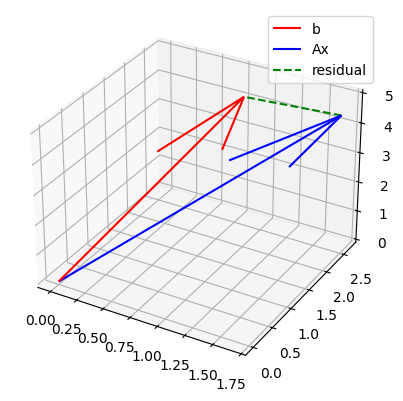

In [43]:
import matplotlib.pyplot as plt
import numpy as np

A = np.array([[1, 0], [0, 1], [1, 1]]) 
b = np.array([1, 2, 5]) 
x_hat = np.linalg.pinv(A) @ b
projection = A @ x_hat

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.quiver(0, 0, 0, b[0], b[1], b[2], color='r', label='b')
ax.quiver(0, 0, 0, projection[0], projection[1], projection[2], color='b', label='Ax')
ax.plot([projection[0], b[0]], [projection[1], b[1]], [projection[2], b[2]], 'g--', label='residual')
ax.legend()
plt.show()

We can define the residual between those two vectors as:
$||Ax-b||^2$

Like for the underdetermined system, we can nicely separate out the vector $b$ into itwo two components: $b = \perp{b} + b_{orthogonal}$ ADD TO THIS 

Now we can take the above residual equation and reformat it: $||Ax-b||^2 = ||\perp{b}||^2 + ||Ax - b_{orth}||^2$. This is the equation we now want to be able to minimize effectively. So to do this, we need to be able to minimize this, which requires us minimizing ||Ax - b_{orth}||^2. 

To minimize that, we can take the derivate with respect to x, which results in $A^TAx = A^Tb$. Assuming that we have full column rank, then we know that $x = (A^TA)^-1A^Tb$. 

With SVD, we would then be able to redefine $Ax^+ = U (\Sigma \Sigma^+) U^Tb$. 

$(\Sigma \Sigma^+)$ is going to be a diagonal matrix, and will essentially remove the components of b that are in the nullspace of $A^T$, so we can see that $Ax^+$ retains the components of b that are in the column space of A, making it the closest possible solution wiht a minimized residual. 


This is essentialy the operation that is also used in any type of linear regression - we try to minimize the error/residual, in this case across a line, to single points. 

## Adding the optimal vector

In this case, we add a vector to $x^+$, so $x = x^+ + z$. 

In the underdetermined case, if z is part of the nullspace of A, then the answer wouldn't change. We would see a slight increase in the minimum norm though, so adding this pertubation would result in a "worse" result, but is still the minimum norm solution. 

The same scenario would likely occur in the overdetermined case. 